# Analisis Spasial, Temporal & Siklus Harian Data GSMaP (NetCDF)
Notebook ini digunakan untuk membaca, menggabungkan, dan menganalisis dataset NetCDF (`.nc`) **GSMaP (Global Satellite Mapping of Precipitation)** dilengkapi overlay batas kecamatan Kebumen (`33.05_kecamatan.geojson`), analisis siklus harian (*diurnal cycle*), serta visualisasi spasial bulanan dengan `Discrete Boundary Normalization`.

### Fitur Utama:
- **Dual Compatibility (Lokal & Kaggle):** Otomatis mendeteksi dataset Kaggle di `/kaggle/input/datasets/jerismeteo/gee-gsmap-kebumen/` dan `/kaggle/input/datasets/jerismeteo/projek-downscale/`.
- **Multi-File NetCDF Merging:** Menggabungkan data per-jam GSMaP multi-tahun secara efisien dengan `xarray`.
- **Analisis Siklus Harian (Diurnal Cycle):** Mengetahui pola jam puncak hujan di Kebumen (00:00 - 23:00).
- **Klimatologi & Peta Spasial Bulanan:** Visualisasi spasial dengan interval diskret ilmiah (`BoundaryNorm`) dan label kecamatan.

In [1]:
import os
import glob
import xarray as xr
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = "DejaVu Sans"
plt.rcParams['font.family'] = "sans-serif"

# ==========================================
# 0. PENGATURAN PATH & PERIODE WAKTU DINAMIS
# ==========================================
IS_KAGGLE = 'KAGGLE_KERNEL_RUN_TYPE' in os.environ

if IS_KAGGLE:
    # Di Kaggle: Gunakan seluruh data yang diunduh GEE_GSMAP (2000 - 2026)
    tahun_filter_mulai = None
    kaggle_gsmap_dir = Path("/kaggle/input/datasets/jerismeteo/gee-gsmap-kebumen")
    if (kaggle_gsmap_dir / "data/gsmap").exists():
        data_dir = kaggle_gsmap_dir / "data/gsmap"
    elif kaggle_gsmap_dir.exists():
        data_dir = kaggle_gsmap_dir
    elif Path("/kaggle/working/data/gsmap").exists():
        data_dir = Path("/kaggle/working/data/gsmap")
    else:
        found_gsmap = glob.glob("/kaggle/input/**/gsmap*", recursive=True)
        data_dir = Path(found_gsmap[0]) if found_gsmap else Path("data/gsmap")
        
    kaggle_geojson = Path("/kaggle/input/datasets/jerismeteo/projek-downscale/33.05_kecamatan.geojson")
    geojson_path = str(kaggle_geojson) if kaggle_geojson.exists() else glob.glob("/kaggle/input/**/33.05_kecamatan.geojson", recursive=True)[0]
    out_dir = Path("/kaggle/working/gsmap_bulanan")
else:
    # Di Lokal: Analisis fokus dari tahun 2020 ke depan (2020 - 2026)
    tahun_filter_mulai = '2020-01-01'
    data_dir = Path("data/gsmap")
    geojson_path = "33.05_kecamatan.geojson"
    out_dir = Path("gsmap_bulanan")

out_dir.mkdir(parents=True, exist_ok=True)
print(f"📌 Environment           : {'Kaggle' if IS_KAGGLE else 'Lokal'}")
print(f"📌 Periode Analisis      : {'Semua Data GEE (2000 - 2026)' if IS_KAGGLE else '2020 s.d. Sekarang'}")
print(f"📌 Direktori Data GSMaP  : {data_dir}")
print(f"📌 Lokasi File GeoJSON   : {geojson_path}")
print(f"📌 Direktori Output Peta : {out_dir}")


📌 Environment           : Kaggle
📌 Periode Analisis      : Semua Data GEE (2000 - 2026)
📌 Direktori Data GSMaP  : /kaggle/input/datasets/jerismeteo/gee-gsmap-kebumen/data/gsmap
📌 Lokasi File GeoJSON   : /kaggle/input/datasets/jerismeteo/projek-downscale/33.05_kecamatan.geojson
📌 Direktori Output Peta : /kaggle/working/gsmap_bulanan


## 1. Memuat & Menggabungkan File NetCDF GSMaP
Menggunakan `xarray.open_mfdataset` untuk memuat semua file `.nc` dari subfolder GSMaP secara otomatis dan efisien.

In [2]:
nc_files = sorted(list(data_dir.glob("**/*.nc")))
print(f"Total file NetCDF GSMaP ditemukan: {len(nc_files)}")

if len(nc_files) == 0:
    raise FileNotFoundError(f"Tidak ada file .nc ditemukan di direktori: {data_dir}")

# Buka seluruh dataset menggunakan xarray
ds_raw = xr.open_mfdataset(nc_files, combine='by_coords')

# Terapkan filter waktu jika di lokal (2020 ke depan)
if tahun_filter_mulai:
    ds = ds_raw.sel(time=slice(tahun_filter_mulai, None))
    print(f"\n🔍 Data difilter untuk periode Lokal: {tahun_filter_mulai} s.d. selesai")
else:
    ds = ds_raw
    print("\n🔍 Menggunakan seluruh rentang data Kaggle GEE")

print("\n--- Informasi Dataset GSMaP yang Dianalisis ---")
print(ds)


Total file NetCDF GSMaP ditemukan: 320


/tmp/ipykernel_16/59946341.py:8: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds_raw = xr.open_mfdataset(nc_files, combine='by_coords')



🔍 Menggunakan seluruh rentang data Kaggle GEE

--- Informasi Dataset GSMaP yang Dianalisis ---
<xarray.Dataset> Size: 32MB
Dimensions:        (time: 233460, y: 5, x: 6)
Coordinates:
  * time           (time) datetime64[ns] 2MB 2000-01-01 ... 2026-08-19T14:00:00
  * y              (y) float64 40B -7.45 -7.55 -7.65 -7.75 -7.85
  * x              (x) float64 48B 109.4 109.5 109.6 109.7 109.8 109.9
Data variables:
    spatial_ref    (time) int64 2MB 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0 0
    precipitation  (time, y, x) float32 28MB dask.array<chunksize=(744, 5, 6), meta=np.ndarray>


## 2. Memuat Peta Vektor Wilayah (GeoJSON Kecamatan Kebumen)

In [3]:
gdf_kec = gpd.read_file(geojson_path)
if gdf_kec.crs != "EPSG:4326":
    gdf_kec = gdf_kec.to_crs("EPSG:4326")

print(f"Berhasil memuat GeoJSON: {len(gdf_kec)} Kecamatan di Kebumen")
gdf_kec.head(3)

Berhasil memuat GeoJSON: 26 Kecamatan di Kebumen


,kd_propinsi,kd_dati2,kd_kecamatan,nm_kecamatan,geometry
0,33,05,001,Ayah,"MULTIPOLYGON Z (((109.41096 -7.77624 0, 109.41..."
1,33,05,002,Buayan,"MULTIPOLYGON Z (((109.46888 -7.75906 0, 109.46..."
2,33,05,003,Puring,"MULTIPOLYGON Z (((109.5242 -7.76568 0, 109.524..."


## 3. Ekstraksi Deret Waktu Rata-rata Wilayah (Areal Mean) & Agregasi Waktu

In [4]:
spatial_dims = [dim for dim in ds['precipitation'].dims if dim != 'time']
da_areal_mean = ds['precipitation'].mean(dim=spatial_dims).to_series()
df_hourly = pd.DataFrame({'rainfall_hourly': da_areal_mean})
df_hourly.index.name = 'DateTime'

# Agregasi Harian, Bulanan, dan Tahunan
df_daily = df_hourly.resample('D').sum().rename(columns={'rainfall_hourly': 'rainfall_daily'})
df_monthly = df_daily.resample('ME').sum().rename(columns={'rainfall_daily': 'rainfall_monthly'})
df_annual = df_daily.resample('YE').sum().rename(columns={'rainfall_daily': 'rainfall_annual'})

print(f"Total jam     : {len(df_hourly)}")
print(f"Total hari    : {len(df_daily)}")
print(f"Total bulan   : {len(df_monthly)}")
print(f"Total tahun   : {len(df_annual)}")

print("\nStatistik Ringkas Harian (mm/hari):")
print(df_daily.describe())

Total jam     : 233460
Total hari    : 9728
Total bulan   : 320
Total tahun   : 27

Statistik Ringkas Harian (mm/hari):
       rainfall_daily
count     9728.000000
mean         6.902258
std         12.134670
min          0.000000
25%          0.000000
50%          1.297259
75%          9.038497
max        152.256607


## 4. Analisis Siklus Harian (*Diurnal Cycle* - Jam Puncak Hujan)
Melihat pada jam berapa (00:00 - 23:00 UTC/WIB) curah hujan paling sering turun dan mencapai intensitas tertinggi di wilayah Kebumen.

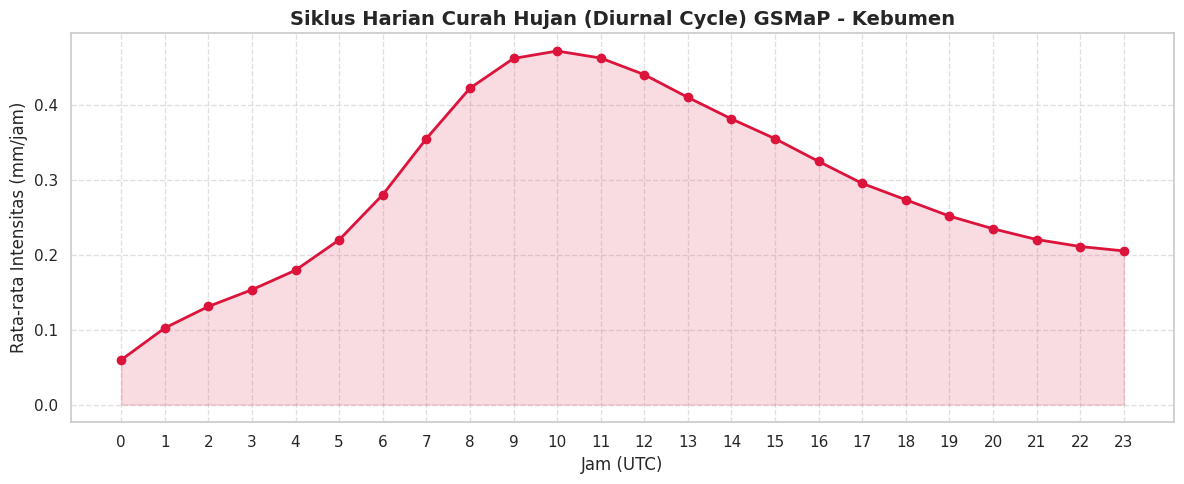

In [5]:
# Hitung rata-rata intensitas hujan per jam (0 - 23)
diurnal_mean = df_hourly.groupby(df_hourly.index.hour).mean()

plt.figure(figsize=(12, 5))
plt.plot(diurnal_mean.index, diurnal_mean['rainfall_hourly'], marker='o', color='crimson', lw=2, markersize=6)
plt.fill_between(diurnal_mean.index, 0, diurnal_mean['rainfall_hourly'], color='crimson', alpha=0.15)

plt.title("Siklus Harian Curah Hujan (Diurnal Cycle) GSMaP - Kebumen", fontsize=14, fontweight='bold')
plt.xlabel("Jam (UTC)", fontsize=12)
plt.ylabel("Rata-rata Intensitas (mm/jam)", fontsize=12)
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig(out_dir / "siklus_harian_diurnal_gsmap.png", dpi=300, bbox_inches='tight')
plt.show()

## 5. Visualisasi Time Series Curah Hujan Harian & Bulanan

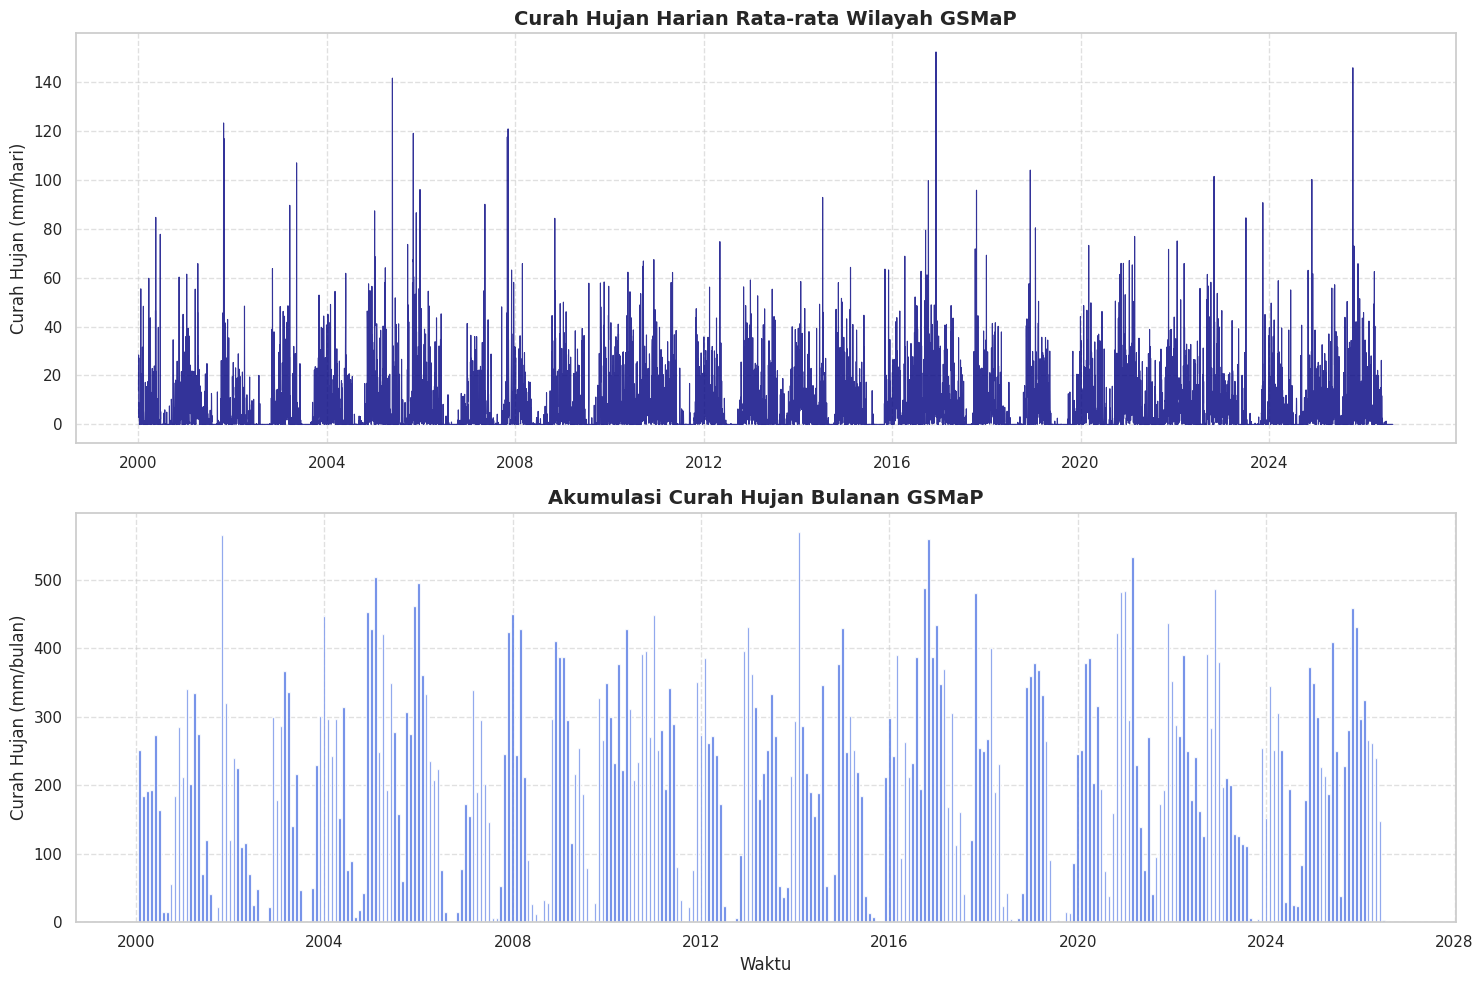

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(15, 10), sharex=False)

# Daily plot
axes[0].plot(df_daily.index, df_daily['rainfall_daily'], color='navy', linewidth=0.8, alpha=0.8)
axes[0].set_title("Curah Hujan Harian Rata-rata Wilayah GSMaP", fontsize=14, fontweight='bold')
axes[0].set_ylabel("Curah Hujan (mm/hari)", fontsize=12)
axes[0].grid(True, linestyle='--', alpha=0.6)

# Monthly plot
axes[1].bar(df_monthly.index, df_monthly['rainfall_monthly'], color='royalblue', width=20, alpha=0.85)
axes[1].set_title("Akumulasi Curah Hujan Bulanan GSMaP", fontsize=14, fontweight='bold')
axes[1].set_ylabel("Curah Hujan (mm/bulan)", fontsize=12)
axes[1].set_xlabel("Waktu", fontsize=12)
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig(out_dir / "timeseries_gsmap.png", dpi=300, bbox_inches='tight')
plt.show()

## 6. Visualisasi Distribusi Spasial Keseluruhan dengan Overlay Peta Kecamatan GeoJSON

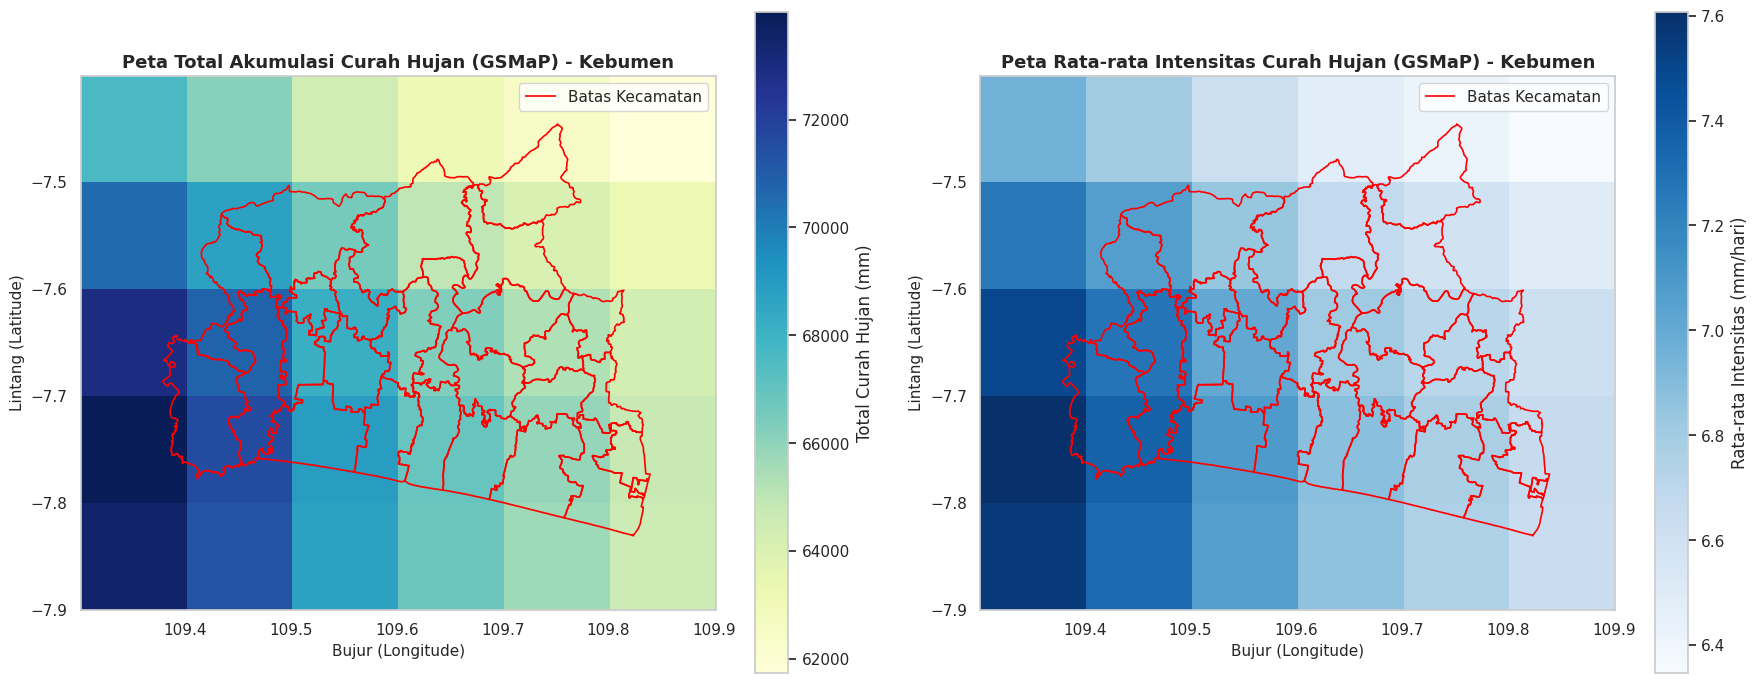

In [7]:
spatial_total = ds['precipitation'].sum(dim='time')
spatial_mean = ds['precipitation'].mean(dim='time') * 24 # Dikonversi ke rata-rata mm/hari

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Peta Total + Overlay GeoJSON
spatial_total.plot(ax=axes[0], cmap='YlGnBu', cbar_kwargs={'label': 'Total Curah Hujan (mm)'})
gdf_kec.boundary.plot(ax=axes[0], color='red', linewidth=1.2, label='Batas Kecamatan')
axes[0].set_title("Peta Total Akumulasi Curah Hujan (GSMaP) - Kebumen", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Bujur (Longitude)", fontsize=11)
axes[0].set_ylabel("Lintang (Latitude)", fontsize=11)
axes[0].legend(loc='upper right')

# Peta Rata-rata + Overlay GeoJSON
spatial_mean.plot(ax=axes[1], cmap='Blues', cbar_kwargs={'label': 'Rata-rata Intensitas (mm/hari)'})
gdf_kec.boundary.plot(ax=axes[1], color='red', linewidth=1.2, label='Batas Kecamatan')
axes[1].set_title("Peta Rata-rata Intensitas Curah Hujan (GSMaP) - Kebumen", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Bujur (Longitude)", fontsize=11)
axes[1].set_ylabel("Lintang (Latitude)", fontsize=11)
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.savefig(out_dir / "distribusi_spasial_gsmap.png", dpi=300, bbox_inches='tight')
plt.show()

## 7. Pola Siklus Klimatologi Bulanan (Januari - Desember)

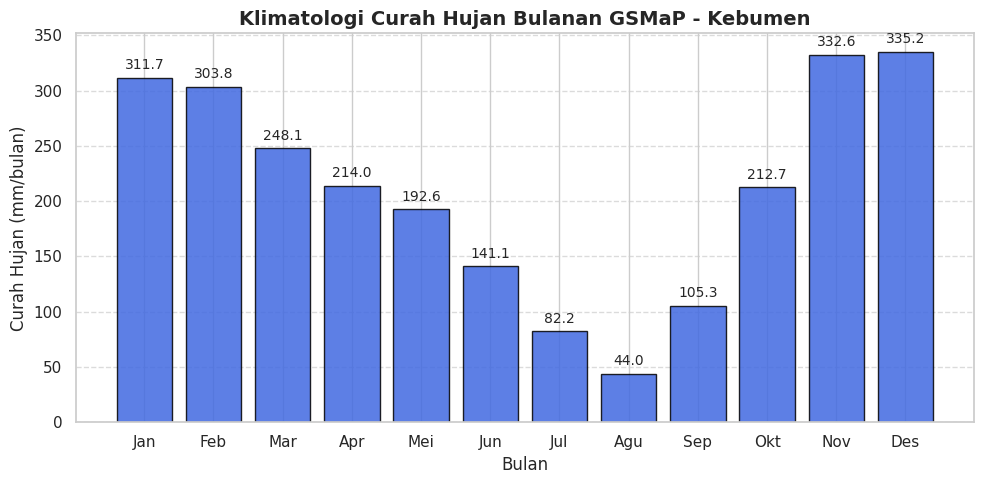

In [8]:
monthly_climatology = df_monthly.groupby(df_monthly.index.month).mean()

plt.figure(figsize=(10, 5))
bars = plt.bar(monthly_climatology.index, monthly_climatology['rainfall_monthly'], color='royalblue', alpha=0.85, edgecolor='black')
plt.title("Klimatologi Curah Hujan Bulanan GSMaP - Kebumen", fontsize=14, fontweight='bold')
plt.xlabel("Bulan", fontsize=12)
plt.ylabel("Curah Hujan (mm/bulan)", fontsize=12)
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'Mei', 'Jun', 'Jul', 'Agu', 'Sep', 'Okt', 'Nov', 'Des'])
plt.grid(True, axis='y', linestyle='--', alpha=0.7)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 5, f'{yval:.1f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig(out_dir / "klimatologi_bulanan_gsmap.png", dpi=300, bbox_inches='tight')
plt.show()

## 8. Visualisasi Spasial Bulanan dengan Discrete Boundary Normalization

In [9]:
def buat_cmap_diskret_ilmiah(bounds_list, nama_palette='YlGnBu'):
    base_cmap = plt.get_cmap(nama_palette)
    norm = mcolors.BoundaryNorm(boundaries=bounds_list, ncolors=base_cmap.N)
    return base_cmap, norm

interval_hujan = [0, 50, 100, 150, 200, 300, 400, 500, 600, 700, 800]
cmap_ilmiah, norm_ilmiah = buat_cmap_diskret_ilmiah(interval_hujan, 'YlGnBu')

minx, miny, maxx, maxy = gdf_kec.total_bounds
pad_x = (maxx - minx) * 0.04
pad_y = (maxy - miny) * 0.04

# Ambil seluruh tahun yang ada pada dataset yang dianalisis
available_years = sorted(pd.to_datetime(ds.time.values).year.unique())
print(f"Tahun yang akan dipetakan ({len(available_years)} tahun): {available_years}")

total_saved = 0
for yr in available_years:
    # Buat subfolder per tahun di dalam folder output
    out_dir_year = out_dir / str(yr)
    out_dir_year.mkdir(parents=True, exist_ok=True)
    
    ds_yr = ds.sel(time=str(yr))
    monthly_data = ds_yr['precipitation'].groupby('time.month').sum()
    months = monthly_data.month.values
    
    for m in months:
        data_m = monthly_data.sel(month=m)
        
        fig, ax = plt.subplots(figsize=(10, 10))
        im = data_m.plot(ax=ax, cmap=cmap_ilmiah, norm=norm_ilmiah, add_colorbar=False)
        gdf_kec.boundary.plot(ax=ax, color='black', linewidth=0.7)
        
        for _, row in gdf_kec.iterrows():
            pt = row['geometry'].representative_point()
            col_name = 'nm_kecamatan' if 'nm_kecamatan' in row else ('KECAMATAN' if 'KECAMATAN' in row else gdf_kec.columns[0])
            ax.annotate(
                row[col_name], 
                xy=(pt.x, pt.y),
                fontsize=7.5, 
                fontweight='bold', 
                ha='center', 
                va='center',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='black', linewidth=0.4, alpha=0.85)
            )
            
        ax.set_xlim(minx - pad_x, maxx + pad_x)
        ax.set_ylim(miny - pad_y, maxy + pad_y)
        
        ax.set_title(
            f"Peta Akumulasi Curah Hujan Bulanan GSMaP - Kebumen\nBulan: {m:02d} Tahun: {yr}", 
            fontsize=13, 
            fontweight='bold', 
            pad=12
        )
        ax.set_xlabel("Longitude", fontsize=11)
        ax.set_ylabel("Latitude", fontsize=11)
        ax.set_xticks([])
        ax.set_yticks([])
        
        cbar = fig.colorbar(
            im, 
            ax=ax, 
            orientation='horizontal', 
            pad=0.05, 
            shrink=0.85, 
            ticks=interval_hujan
        )
        cbar.set_label('Total Curah Hujan Bulanan (mm)', fontsize=11)
        
        png_path = out_dir_year / f"gsmap_{yr}_{m:02d}.png"
        fig.savefig(png_path, dpi=300, bbox_inches='tight')
        plt.close(fig)
        total_saved += 1
        
    print(f"  ✓ Selesai tahun {yr}: tersimpan di {out_dir_year}/")

print(f"\n🎉 Total {total_saved} file peta bulanan berhasil disimpan rapi ke subfolder tahunan di: {out_dir}")


Tahun yang akan dipetakan (27 tahun): [2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]
  ✓ Selesai tahun 2000: tersimpan di /kaggle/working/gsmap_bulanan/2000/
  ✓ Selesai tahun 2001: tersimpan di /kaggle/working/gsmap_bulanan/2001/
  ✓ Selesai tahun 2002: tersimpan di /kaggle/working/gsmap_bulanan/2002/
  ✓ Selesai tahun 2003: tersimpan di /kaggle/working/gsmap_bulanan/2003/
  ✓ Selesai tahun 2004: tersimpan di /kaggle/working/gsmap_bulanan/2004/
  ✓ Selesai tahun 2005: tersimpan di /kaggle/working/gsmap_bulanan/2005/
  ✓ Selesai tahun 2006: tersimpan di /kaggle/working/gsmap_bulanan/2006/
  ✓ Selesai tahun 2007: tersimpan di /kaggle/working/gsmap_bulanan/2007/
  ✓ Selesai tahun 2008: tersimpan di /kaggle/working/gsmap_bulanan/2008/
  ✓ Selesai tahun 2009: tersimpan di /kaggle/working/gsmap_bulanan/2009/
  ✓ Selesai tahun 2010: tersimpan di /kaggle/working/gsmap_bulanan/20